<a href="https://colab.research.google.com/github/MuhammadAhmedMasood/deep-learning-pytorch/blob/main/02_PyTorch_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. Neural Network classification with PyTorch

Classification is a problem of predicting whether something is one thing or another.

In [43]:
# make classification data:
import sklearn

In [44]:
from sklearn.datasets import make_circles
n_samples = 1000

X, y = make_circles(n_samples, noise = 0.003, random_state = 42)

len(X), len(y)

(1000, 1000)

In [45]:
print(X[:5])
print(f"\n{y[:5]}")

[[ 0.77049941  0.21095396]
 [-0.78602977  0.13242465]
 [-0.79586178  0.10756813]
 [-0.34593416  0.72076375]
 [ 0.43762495 -0.89913707]]

[1 1 1 1 0]


In [46]:
print(y)

[1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1
 1 1 0 0 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 1 0 0 1 0 0 1 0 1 1 1 1 0 1 0 0 1 1
 0 0 1 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0 1 1 1 1 0 1 1
 1 1 1 0 0 0 1 1 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1 0 0 0 0 0 0 0 1 0 1 1 1 0
 1 0 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 1
 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1 0 1 0 0 1 1 1 0 1 0 1 1 0 1
 1 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1
 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1 1 1 1 0 0 0
 1 0 0 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 1 0 1
 1 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1
 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 1 1 0 1 1 0 0 1 0 1 0 0 0 1 1 0 0 1 1 1 1 1
 0 0 1 1 1 1 0 1 1 1 1 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 1 1
 1 1 1 0 1 1 1 1 0 0 0 1 1 1 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 1 1 1 1 1 1
 0 0 0 1 0 0 0 0 0 1 1 1 

In [47]:
# Make a DataFrame:

import pandas as pd

df = pd.DataFrame({
    "X1": X[:,0],
    "X2": X[:,1],
    "label" : y
})
df.head(10)

,X1,X2,label
0,0.770499,0.210954,1
1,-0.786030,0.132425,1
2,-0.795862,0.107568,1
3,-0.345934,0.720764,1
4,0.437625,-0.899137,0
5,-0.492824,0.633771,1
6,-0.010412,0.800278,1
7,0.787565,0.131875,1
8,-0.160723,-0.784841,1
9,-0.136160,0.993566,0


In [48]:
df.label.value_counts()

,count
label,
1,500
0,500


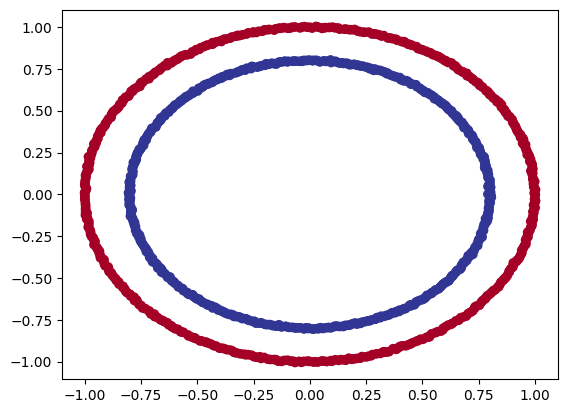

In [49]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,1],c=y,cmap = plt.cm.RdYlBu )

In [50]:
X.shape, y.shape

((1000, 2), (1000,))

In [51]:
X

array([[ 0.77049941,  0.21095396],
       [-0.78602977,  0.13242465],
       [-0.79586178,  0.10756813],
       ...,
       [-0.14860458, -0.788248  ],
       [ 0.68312855, -0.73282192],
       [ 0.284623  ,  0.95905205]])

In [52]:
X_sample = X[0]
y_sample = y[0]
print(f"values for one sample of: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of: {X_sample.shape} and the same for y: {y_sample.shape}")

values for one sample of: [0.77049941 0.21095396] and the same for y: 1
Shapes for one sample of: (2,) and the same for y: ()


In [53]:
# getting into tensors and train test split:
import torch
torch.__version__

'2.11.0+cu128'

In [54]:
type(X)

numpy.ndarray

In [55]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7705,  0.2110],
         [-0.7860,  0.1324],
         [-0.7959,  0.1076],
         [-0.3459,  0.7208],
         [ 0.4376, -0.8991]]),
 tensor([1., 1., 1., 1., 0.]))

In [56]:
X.dtype, y.dtype

(torch.float32, torch.float32)

In [57]:
# split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [58]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [59]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [60]:
X_train

tensor([[ 0.6319, -0.4914],
        [ 0.6710, -0.7372],
        [-0.9906, -0.1476],
        ...,
        [ 0.0355, -1.0024],
        [ 0.9909,  0.1520],
        [ 0.5552, -0.5757]])

The device agnostic code is setup.

We'll create a model that:
1. Subclasses `nn.Module` (almost all models in PyTorch subclass `nn.Module`)
2. Create 2 `nn.Linear()` layers that are capable of handling the shape of our data
3. Define a `forward()` method that outlines the forward pass (forward propagation of the model
4. Instantiate an instance of our model and send it to the target `device`

In [61]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)
  def forward(self, x: torch.tensor):
    return self.layer_2(self.layer_1(x)) # x -> self.layer_1 -> self.layer_2

model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [62]:
device

'cuda'

In [63]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [64]:
# using nn.Sequential:

model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [65]:
# can also fit the nn.Sequential in the class itself as well. Knowing how to use the class approach is impt when we more complex forward method

In [66]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]], device='cuda:0')),
             ('0.bias',
              tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]], device='cuda:0')),
             ('1.bias', tensor([-0.1213], device='cuda:0'))])

In [67]:
# Making predictions
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions:\n{torch.round(untrained_preds[:10])}")
print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions:
tensor([[-0.],
        [-0.],
        [0.],
        [-0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [-0.]], device='cuda:0')

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [68]:
X_test[:10], y_test[:10]

(tensor([[-0.3923,  0.6948],
         [-0.0437,  0.9949],
         [-0.7256, -0.3298],
         [-0.3281,  0.9453],
         [ 0.4260, -0.6823],
         [ 0.6180, -0.5161],
         [ 0.8268,  0.5655],
         [ 0.9844,  0.1877],
         [-0.7676, -0.2260],
         [ 0.0619,  0.9956]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

In [69]:
# Setup loss function and optimizer

# regression -> MAE (L1 loss) or MSE
# classification -> binary cross entropy or categorical cross entropy

# For optimzers, 2 most common are: SGD or Adam


loss_fn = nn.BCEWithLogitsLoss() # sigmoid activation function is built-in. This is similar to having inputs going to sigmoid and then BCELoss:

# nn.Sequential(nn.Sigmoid(), nn.BCELoss())
# The reason we use nn.BCEWithLogitsLoss() is it has more numerical stability, see PyTorch documentation

optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.1)

In [70]:
# accuracy - TP/TP+FP * 100

def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

In [71]:
# our model's outputs are logits - and we can convert them to prediction probabilities by passing through some activation function
# for example, sigmoid for binary classification, softmax for multiclass classification
# then we convert our model's predictions to prediction labels by either rounding them up or using argmax()

In [72]:
# viewing the first 5 outputs of the forward pass on the test data:
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.0379],
        [-0.0440],
        [ 0.0891],
        [-0.0710],
        [ 0.2895]], device='cuda:0')

In [73]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [74]:
# using sigmoid on our logits:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4905],
        [0.4890],
        [0.5222],
        [0.4822],
        [0.5719]], device='cuda:0')

In [75]:
y_preds = torch.round(y_pred_probs)
y_preds

tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.]], device='cuda:0')

In [76]:
# in full:
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# check equality
print(torch.eq(y_pred_labels.squeeze(), y_preds.squeeze()))
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 1., 0., 1.], device='cuda:0')

In [77]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [78]:
# Training

torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 200

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):

  model_0.train()

  # Feed Forward
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels


  # calculate loss/ accuracy

  # loss = loss_fn(torch.sigmoid(y_logits), # nn.BCELoss expects prediction probabilities as input
  #               y_train)

  loss = loss_fn(y_logits, # nn.BCEWithLogitsLoss expects raw logits as input
                 y_train)
  acc = accuracy_fn(y_true = y_train, y_pred = y_pred)

  # optimizer
  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  # testing
  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = accuracy_fn(y_true = y_test,
                           y_pred = test_pred)

    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69788, Acc: 52.12% | Test loss: 0.69450, Test acc: 57.50%
Epoch: 10 | Loss: 0.69585, Acc: 51.25% | Test loss: 0.69314, Test acc: 53.50%
Epoch: 20 | Loss: 0.69487, Acc: 51.50% | Test loss: 0.69261, Test acc: 50.00%
Epoch: 30 | Loss: 0.69433, Acc: 51.25% | Test loss: 0.69242, Test acc: 49.50%
Epoch: 40 | Loss: 0.69400, Acc: 50.88% | Test loss: 0.69236, Test acc: 50.50%
Epoch: 50 | Loss: 0.69378, Acc: 50.62% | Test loss: 0.69237, Test acc: 50.00%
Epoch: 60 | Loss: 0.69362, Acc: 50.38% | Test loss: 0.69242, Test acc: 51.00%
Epoch: 70 | Loss: 0.69351, Acc: 50.12% | Test loss: 0.69248, Test acc: 51.50%
Epoch: 80 | Loss: 0.69342, Acc: 50.25% | Test loss: 0.69255, Test acc: 50.50%
Epoch: 90 | Loss: 0.69336, Acc: 50.38% | Test loss: 0.69263, Test acc: 50.50%
Epoch: 100 | Loss: 0.69331, Acc: 49.88% | Test loss: 0.69271, Test acc: 52.50%
Epoch: 110 | Loss: 0.69327, Acc: 49.88% | Test loss: 0.69279, Test acc: 53.50%
Epoch: 120 | Loss: 0.69324, Acc: 49.88% | Test loss: 0.69286, T

In [79]:
# predictions and evaluate
import requests
from pathlib import Path

if Path("helper_function.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

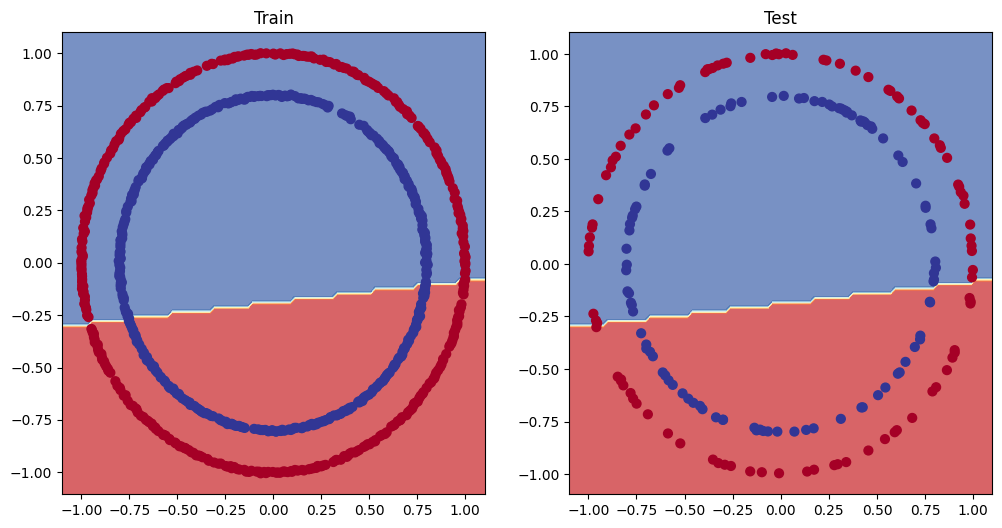

In [80]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [81]:
# improving a model:

# add more layers - give model more chances to learn
# add more hidden units
# fit for longer
# changing activation functions
# changing learning rate
# changing loss function